# Text-as-Image Compression: Condition A vs Condition B
### Vision Language Model Evaluation with `gemma4:31b`

This notebook demonstrates:
1. **Load/Connect to Gemma 4** via Ollama API (`gemma4:31b`)
2. **Define simple text & question**
3. **Ask question using text only** (Baseline - Condition A)
4. **Convert the SAME text into an image** (Text-as-Image rasterization)
5. **Ask the same question using the image** (Main experiment - Condition B)
6. **Compare both answers side-by-side with latency**

In [1]:
# 1. Load Gemma 4 & verify connection
import time
import io
from PIL import Image, ImageDraw, ImageFont
from ollama import chat

MODEL_NAME = 'gemma4:31b'

# Warmup / connection check
warmup_response = chat(
    model=MODEL_NAME,
    messages=[{'role': 'user', 'content': 'Hello!'}]
)
print("Model Status:", warmup_response.message.content)

Model Status: Hello! How can I help you today?


In [2]:
# 2. Define simple text and question
context_text = (
    "Project Apollo was initiated in 1961. "
    "The landing module was named The Eagle, and the target crater was named Sea of Tranquility. "
    "The mission commander carried secret authorization code: 9482-OMEGA."
)

question = "What was the name of the landing module and what was the secret authorization code?"

print("--- CONTEXT TEXT ---")
print(context_text)
print("\n--- QUESTION ---")
print(question)

--- CONTEXT TEXT ---
Project Apollo was initiated in 1961. The landing module was named The Eagle, and the target crater was named Sea of Tranquility. The mission commander carried secret authorization code: 9482-OMEGA.

--- QUESTION ---
What was the name of the landing module and what was the secret authorization code?


In [3]:
# 3. Ask question using TEXT (Condition A: Baseline)
start_time = time.time()

response_text = chat(
    model=MODEL_NAME,
    messages=[{
        'role': 'user',
        'content': f"Context:\n{context_text}\n\nQuestion: {question}"
    }]
)

latency_text = time.time() - start_time
answer_text = response_text.message.content

print(f"Answer (Text Query) [{latency_text:.2f}s]:")
print(answer_text)

Answer (Text Query) [0.64s]:
The landing module was named The Eagle, and the secret authorization code was 9482-OMEGA.


Rendered image saved as context_rendered.png (Size: (750, 162) )


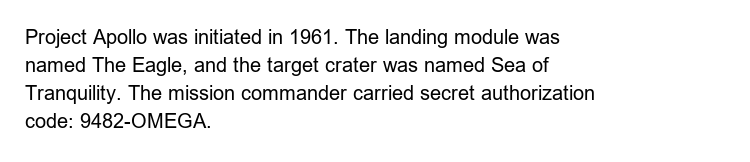

In [4]:
# 4. Convert SAME text into image
def render_text_to_image(text, font_size=20, padding=25, bg_color='white', text_color='black'):
    try:
        font = ImageFont.truetype("arial.ttf", font_size)
    except IOError:
        font = ImageFont.load_default()

    # Wrap text into readable lines
    import textwrap
    lines = textwrap.wrap(text, width=65)
    
    line_height = font_size + 8
    img_width = 750
    img_height = 2 * padding + len(lines) * line_height

    image = Image.new("RGB", (img_width, img_height), color=bg_color)
    draw = ImageDraw.Draw(image)

    y = padding
    for line in lines:
        draw.text((padding, y), line, fill=text_color, font=font)
        y += line_height

    return image

# Generate the image
rendered_image = render_text_to_image(context_text)
rendered_image.save("context_rendered.png")
print("Rendered image saved as context_rendered.png (Size:", rendered_image.size, ")")

# Display inside notebook
rendered_image

In [5]:
# 5. Ask same question using IMAGE (Condition B: Main Experiment)
buf = io.BytesIO()
rendered_image.save(buf, format='PNG')
image_bytes = buf.getvalue()

start_time = time.time()

response_image = chat(
    model=MODEL_NAME,
    messages=[{
        'role': 'user',
        'content': f"Answer the following question strictly based on the text rendered in the attached image: {question}",
        'images': [image_bytes]
    }]
)

latency_image = time.time() - start_time
answer_image = response_image.message.content

print(f"Answer (Image Query) [{latency_image:.2f}s]:")
print(answer_image)

Answer (Image Query) [0.80s]:
The landing module was named The Eagle, and the secret authorization code was 9482-OMEGA.


In [6]:
# 6. Print answers, token counts, and Compression Ratio (CR)
prompt_tokens_text = getattr(response_text, 'prompt_eval_count', None)
gen_tokens_text = getattr(response_text, 'eval_count', None)

prompt_tokens_image = getattr(response_image, 'prompt_eval_count', None)
gen_tokens_image = getattr(response_image, 'eval_count', None)

# Compression Ratio formula from Methodology: CR = (m + q) / (k + q)
if prompt_tokens_text and prompt_tokens_image:
    compression_ratio = prompt_tokens_text / prompt_tokens_image
else:
    compression_ratio = None

print('=' * 75)
print('EXPERIMENT COMPARISON: CONDITION A (TEXT) vs CONDITION B (IMAGE)')
print('=' * 75)
print(f'Model: {MODEL_NAME}\n')
print('--- [1] CONDITION A: TEXT-ONLY BASELINE ---')
print(f'Prompt Tokens (m + q) : {prompt_tokens_text}')
print(f'Generated Tokens      : {gen_tokens_text}')
print(f'Latency               : {latency_text:.2f}s')
print(f'Answer:\n{answer_text}\n')
print('-' * 75)
print('--- [2] CONDITION B: TEXT-AS-IMAGE EXPERIMENTAL ---')
print(f'Visual + Query Tokens (k + q) : {prompt_tokens_image}')
print(f'Generated Tokens             : {gen_tokens_image}')
print(f'Latency                      : {latency_image:.2f}s')
print(f'Answer:\n{answer_image}\n')
print('=' * 75)
print('METRICS & COMPRESSION RATIO (CR) SUMMARY')
print('=' * 75)
if compression_ratio is not None:
    print(f'CR = (m + q) / (k + q) = {prompt_tokens_text} / {prompt_tokens_image} = {compression_ratio:.4f}')
    if compression_ratio > 1.0:
        print(f'=> Text-as-Image saved {(1.0 - 1.0/compression_ratio)*100:.1f}% prompt tokens!')
    else:
        print(f'=> For short text ({prompt_tokens_text} tokens), the visual token grid ({prompt_tokens_image} tokens) has CR < 1.0.')
        print('   As context length (m) grows in benchmarks (500 to 5000 tokens), CR exceeds 1.0.')
print('=' * 75)


EXPERIMENT COMPARISON: CONDITION A (TEXT) vs CONDITION B (IMAGE)
Model: gemma4:31b

--- [1] CONDITION A: TEXT-ONLY BASELINE ---
Prompt Tokens (m + q) : 82
Generated Tokens      : 24
Latency               : 0.64s
Answer:
The landing module was named The Eagle, and the secret authorization code was 9482-OMEGA.

---------------------------------------------------------------------------
--- [2] CONDITION B: TEXT-AS-IMAGE EXPERIMENTAL ---
Visual + Query Tokens (k + q) : 298
Generated Tokens             : 24
Latency                      : 0.80s
Answer:
The landing module was named The Eagle, and the secret authorization code was 9482-OMEGA.

METRICS & COMPRESSION RATIO (CR) SUMMARY
CR = (m + q) / (k + q) = 82 / 298 = 0.2752
=> For short text (82 tokens), the visual token grid (298 tokens) has CR < 1.0.
   As context length (m) grows in benchmarks (500 to 5000 tokens), CR exceeds 1.0.
